# Project 2: Wine Quality

Author: Michael Mboudjeka

ID: 1231228897

Date: February 23, 2025

# The Introduction to the Datasets and the Problems

This project regards the two Wine Quality datasets created by Paulo Cortez, A. Cerdeira, F. Almeida, T. Matos, and J. Reis. Based on a series of physicochemical tests, these datasets aim to model the wine quality of vinho verde wine samples from north of Portugal, with one dataset corresponding to red vinho verde wine samples and the other dataset corresponding to white vinho verde wine samples. Consisting of several thousand observations total, both datasets have eleven feature variables: Fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol. The datasets also have a single target variable, quality, which is a score ranging from 0 to 10. Lastly, the datasets have a color variable, which simply denotes the color of each wine sample, red or white. Both datasets can be accessed <a href=https://archive.ics.uci.edu/dataset/186/wine+quality>here.</a>

In other words, the two datasets contain 11 input variables, 1 output variable, and 1 categorical variable. Since this data aims to measure the quality of each wine sample, I wish to answer the following questions:

- <b>Which feature variables have the largest impact on wine quality for each dataset?</b>
- <b>How, if at all, does the impact of each feature variable differ depending on the wine color?</b>
- <b>Generally speaking, what color of wine tends to yield better quality, red or white?</b>
- <b>In terms of the feature variables, what are the general differences between red and white wine?</b>
- <b>In terms of quality, is the wine quality normally distributed for the red wine samples? How about the white wine samples?</b>

# Importing the Datasets and the Necessary Libraries

To properly manipulate our data and make observations, we will need seven libraries in particular: Numpy, Matplotlib, Pandas, Seaborn, Scipy, Statsmodels, and Scikit-Learn. Numpy will allow us to effectively and easily work with arrays, Matplotlib will allow us to create and edit both static and interactive plots, Pandas will enable us to store our data into data frames and work with those data frames for analysis, Seaborn will broaden the capabilities of Matplotlib and improve our plots, Scipy will provide us with various statistical functions, probability distributions, and statistical tests to use on our data, Statsmodels will grant us access to a variety of statistical models, and Scikit-Learn will grant us a convenient interface for implementing regression models. In addition, we should import the warnings library so that we can then make our code ignore those warnings, resulting in a cleaner output.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from scipy.stats import normaltest
from scipy.stats import kstest
from scipy.stats import jarque_bera
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

Now that we have our necessary packages, we can now download our data using Pandas' <code>read_csv()</code> function:

In [2]:
dfr = pd.read_csv('winequality-red.csv', sep = ';')
dfw = pd.read_csv('winequality-white.csv', sep = ';')

# Examining and Cleaning Up Our Data

Before we can start making observations about our data, we should first make sure that everything in these datasets matches the description of the data and that nothing is missing. First, let's check the names of the columns (variables) in each dataset using the <code>columns</code> attribute:

In [3]:
print(dfr.columns)
print(dfw.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


The column names listed for both datasets are "fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol", and "quality", which matches the description. Only the "color" variable is missing, but considering the datasets are separated by wine color anyway, this makes sense.

Next, let's check to make sure that there aren't any NA values in the datasets that might skew our data observations, which can be done through a combination of Pandas' <code>isna()</code> and <code>sum()</code> functions:

In [4]:
print(dfr.isna().sum().sum())
print(dfw.isna().sum().sum())

0
0


According to the results of these functions, there are 0 NA values in each dataset's entirety, ensuring that our data won't be skewed when making our observations. Now, according to the description of the data, the "quality" variable is an integer ranging from 0 to 10, so let's double check this fact using Pandas' <code>unique()</code> function:

In [5]:
print(dfr['quality'].unique())
print(dfw['quality'].unique())

[5 6 7 4 8 3]
[6 5 7 8 4 3 9]


All the unique quality values in each dataset are between 0 and 10, which matches the data's description. Now, let's make a few general observations about our data to work towards answering our questions. First, let's see how many observations each dataset contains using the <code>shape</code> attribute provided by Numpy:

In [6]:
print(dfr.shape)
print(dfw.shape)

(1599, 12)
(4898, 12)


According to these results, the red wine dataset has 1599 samples but the white wine dataset has 4898 samples; the white wine dataset has a little over triple the amount of samples compared to the red wine dataset. This is something to note, especially as we answer our questions comparing the two datasets. Let's get some more information regarding the datasets using Pandas' <code>info()</code> function:

In [7]:
print(dfr.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [8]:
print(dfw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


Looking at the information tables produced by <code>info()</code>, we reaffirm the variable's names and the number of samples in each dataset, and we can see that all the values in each variable are non-null, reconfirming that there are no NA values in our data. Furthermore, we can observe that all eleven of the feature variables are floating point numbers, whereas the "quality" variable is an integer, which is supported by our earlier observations with <code>unique()</code>. The fact that all our variables are numbers is quite useful, as it will make it easier to observe the effects of our feature variables on quality. 

Now that we know that our data looks as it should according to the data description and that we have a good idea of what each variable is like, we can start to analyse our data to work towards answering our questions.

# Data Analysis

Let's start by comparing our two datasets. To get the average values of each variable in our datasets, we can simply use Pandas' <code>mean()</code> function. We'll start by assessing the red wine dataset:

In [9]:
redAverages = dfr.mean()
print(redAverages)

fixed acidity            8.319637
volatile acidity         0.527821
citric acid              0.270976
residual sugar           2.538806
chlorides                0.087467
free sulfur dioxide     15.874922
total sulfur dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
quality                  5.636023
dtype: float64


Now, let's take a look at the average values of the white wine dataset:

In [10]:
whiteAverages = dfw.mean()
print(whiteAverages)

fixed acidity             6.854788
volatile acidity          0.278241
citric acid               0.334192
residual sugar            6.391415
chlorides                 0.045772
free sulfur dioxide      35.308085
total sulfur dioxide    138.360657
density                   0.994027
pH                        3.188267
sulphates                 0.489847
alcohol                  10.514267
quality                   5.877909
dtype: float64


By looking at these two resulting sets of means, we can see that the values noticeably differ between the two datasets, with some differing more than others, and we can more clearly see the difference between the datasets' means by subtracting the red wine's means by the white wine's means:

In [11]:
diffAverages = redAverages - whiteAverages
print(diffAverages)

fixed acidity            1.464850
volatile acidity         0.249579
citric acid             -0.063216
residual sugar          -3.852609
chlorides                0.041694
free sulfur dioxide    -19.433163
total sulfur dioxide   -91.892865
density                  0.002719
pH                       0.122847
sulphates                0.168302
alcohol                 -0.091284
quality                 -0.241887
dtype: float64


Looking at this set of mean differences, citric acid, residual sugar, free sulfur dioxide, total sulfur dioxide, alcohol, and quality yield negative mean differences, indicating that white wine has higher levels of those substances/properties than red wine on average. Meanwhile, fixed acidity, volatile acidity, chlorides, density, pH, and sulphates yield positive mean differences, indicating that red wine has higher levels of those substances/properties than white wine on average. To ensure that these mean differences are statistically significant (and since the datasets are different sizes), we can conduct Welch's t-test on these variables using the <code>ttest_ind()</code> function provided by Scipy.

In [12]:
t_stat_FA, p_value_FA = stats.ttest_ind(dfr["fixed acidity"], dfw["fixed acidity"], equal_var = False)
print(f"Fixed acidity: t-statistic = {t_stat_FA}, p-value = {p_value_FA}")

Fixed acidity: t-statistic = 32.42271096728916, p-value = 5.668160586754427e-183


In [13]:
t_stat_VA, p_value_VA = stats.ttest_ind(dfr["volatile acidity"], dfw["volatile acidity"], equal_var = False)
print(f"Volatile acidity: t-statistic = {t_stat_VA}, p-value = {p_value_VA}")

Volatile acidity: t-statistic = 53.05909253166281, p-value = 0.0


In [14]:
t_stat_CA, p_value_CA = stats.ttest_ind(dfr["citric acid"], dfw["citric acid"], equal_var = False)
print(f"Citric acid: t-statistic = {t_stat_CA}, p-value = {p_value_CA}")

Citric acid: t-statistic = -12.228986494710666, p-value = 3.172970027090653e-33


In [15]:
t_stat_RS, p_value_RS = stats.ttest_ind(dfr["residual sugar"], dfw["residual sugar"], equal_var = False)
print(f"Residual sugar: t-statistic = {t_stat_RS}, p-value = {p_value_RS}")

Residual sugar: t-statistic = -47.80223738233335, p-value = 0.0


In [16]:
t_stat_C, p_value_C = stats.ttest_ind(dfr["chlorides"], dfw["chlorides"], equal_var = False)
print(f"Chlorides: t-statistic = {t_stat_C}, p-value = {p_value_C}")

Chlorides: t-statistic = 34.24021084875179, p-value = 6.094753845207099e-199


In [17]:
t_stat_FSD, p_value_FSD = stats.ttest_ind(dfr["free sulfur dioxide"], dfw["free sulfur dioxide"], equal_var = False)
print(f"Free sulfur dioxide: t-statistic = {t_stat_FSD}, p-value = {p_value_FSD}")

Free sulfur dioxide: t-statistic = -54.427947693552866, p-value = 0.0


In [18]:
t_stat_TSD, p_value_TSD = stats.ttest_ind(dfr["total sulfur dioxide"], dfw["total sulfur dioxide"], equal_var = False)
print(f"Total sulfur dioxide: t-statistic = {t_stat_TSD}, p-value = {p_value_TSD}")

Total sulfur dioxide: t-statistic = -89.87205884782446, p-value = 0.0


In [19]:
t_stat_D, p_value_D = stats.ttest_ind(dfr["density"], dfw["density"], equal_var = False)
print(f"Density: t-statistic = {t_stat_D}, p-value = {p_value_D}")

Density: t-statistic = 42.70851107543416, p-value = 0.0


In [20]:
t_stat_pH, p_value_pH = stats.ttest_ind(dfr["pH"], dfw["pH"], equal_var = False)
print(f"pH: t-statistic = {t_stat_pH}, p-value = {p_value_pH}")

pH: t-statistic = 27.775496831893292, p-value = 2.3422645384856303e-149


In [21]:
t_stat_S, p_value_S = stats.ttest_ind(dfr["sulphates"], dfw["sulphates"], equal_var = False)
print(f"Sulphates: t-statistic = {t_stat_S}, p-value = {p_value_S}")

Sulphates: t-statistic = 37.05590507280873, p-value = 1.6788419009056876e-231


In [22]:
t_stat_A, p_value_A = stats.ttest_ind(dfr["alcohol"], dfw["alcohol"], equal_var = False)
print(f"Alcohol: t-statistic = {t_stat_A}, p-value = {p_value_A}")

Alcohol: t-statistic = -2.8590287839639132, p-value = 0.004277779864993422


In [23]:
t_stat_Q, p_value_Q = stats.ttest_ind(dfr["quality"], dfw["quality"], equal_var = False)
print(f"Quality: t-statistic = {t_stat_Q}, p-value = {p_value_Q}")

Quality: t-statistic = -10.149363059143164, p-value = 8.168348870049682e-24


In all of these cases, the t-statistic is in double digits and the p-value is extremely tiny, being reported as zero in some cases. The only notable exception is in the alcohol variable, with a t-statistic of around -2.859 and a p-value of around 0.0043, and even then the p-value is far less than 0.05. This indicates that the mean differences of all the variables are highly significant. This is likely due, at least in part, to the vast sample size of both datasets.

Now, to be even more certain that the mean differences are significant, we can use Cohen's d to measure the effect size, or how large the differences are. While Welch's t-test measures the statistical significance of mean differences, Cohen's d measures their practical significance. The formula for Cohen's d is the first mean minus the second mean divided by the pooled standard deviation, and we can create a function using Numpy to streamline this calculation:

In [24]:
def cohens_d(s1, s2):
    n1, n2 = len(s1), len(s2)
    m1, m2 = np.mean(s1), np.mean(s2)
    v1, v2 = np.var(s1, ddof = 1), np.var(s2, ddof = 1)
    pooled = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    d = (m1 - m2) / pooled
    return d

Now we can use this function to calculate the Cohen's d for each variable for the datasets:

In [25]:
print(f'Fixed acidity: {cohens_d(dfr["fixed acidity"], dfw["fixed acidity"])}')
print(f'Volatile acidity: {cohens_d(dfr["volatile acidity"], dfw["volatile acidity"])}')
print(f'Citric acid: {cohens_d(dfr["citric acid"], dfw["citric acid"])}')
print(f'Residual sugar: {cohens_d(dfr["residual sugar"], dfw["residual sugar"])}')
print(f'Chlorides: {cohens_d(dfr["chlorides"], dfw["chlorides"])}')
print(f'Free sulfur dioxide: {cohens_d(dfr["free sulfur dioxide"], dfw["free sulfur dioxide"])}')
print(f'Total sulfur dioxide: {cohens_d(dfr["total sulfur dioxide"], dfw["total sulfur dioxide"])}')
print(f'Density: {cohens_d(dfr["density"], dfw["density"])}')
print(f'pH: {cohens_d(dfr["pH"], dfw["pH"])}')
print(f'Sulphates: {cohens_d(dfr["sulphates"], dfw["sulphates"])}')
print(f'Alcohol: {cohens_d(dfr["alcohol"], dfw["alcohol"])}')
print(f'Quality: {cohens_d(dfr["quality"], dfw["quality"])}')

Fixed acidity: 1.2933706677471952
Volatile acidity: 2.001546443889642
Citric acid: -0.4428295967044044
Residual sugar: -0.8639481320696707
Chlorides: 1.38604107459669
Free sulfur dioxide: -1.2415425323413447
Total sulfur dioxide: -2.277508080344039
Density: 0.9850351942126737
pH: 0.809049224295666
Sulphates: 1.2950364016758988
Alcohol: -0.07657051761217168
Quality: -0.27896618448753385


The results of Cohen's d are classified as follows: Negligible for value magnitudes under 0.2, small for value magnitudes between 0.2 and 0.5, medium for value magnitudes between 0.5 and 0.8, and large for value magnitudes over 0.8. Going off of this guide, alcohol has a negligible effect size, citric acid and quality have small effect sizes, and the other nine variables have large effect sizes, especially volatile acidity and total sulfur dioxide.

So, while the mean differences of all the variables in the datasets are highly statistically significant, of those variables:

- Fixed acidity, volatile acidity, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, and sulphates all differ significantly in a practical sense between red wine and white wine.
- Citric acid and quality both differ a small amount in a practical sense between red wine and white wine.
- Alcohol differs by a negligible amount in a practical sense between red wine and white wine.

So, with all these observations about mean differences, Welch's t-tests, and Cohen's d values in mind, we can come up with answers to two of our central questions:

- <b>Generally speaking, white wine tends to have slightly higher quality than red wine overall.</b>
- <b>In terms of feature variables, red and white wine differ in the following ways:</b>
    - <b>Red wine has significantly higher fixed acidity, noticably higher volatile acidity, somewhat more chlorides, slightly higher density, noticably higher pH, and noticably more sulphates.</b>
    - <b>White wine has somewhat higher citric acid, significantly higher residual sugar, significantly higher free sulfur dioxide, significantly higher total sulfur dioxide, and marginally more alcohol.</b>

Now, let's see whether or not the red wine and white wine datasets are normally distributed in terms of quality, and Python provides a few ways of doing so. One method is to create a histogram with the data, and we can do exactly that with the help of Matplotlib and Seaborn:

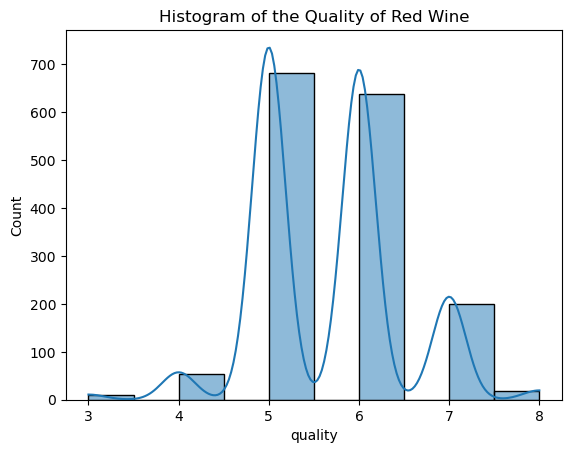

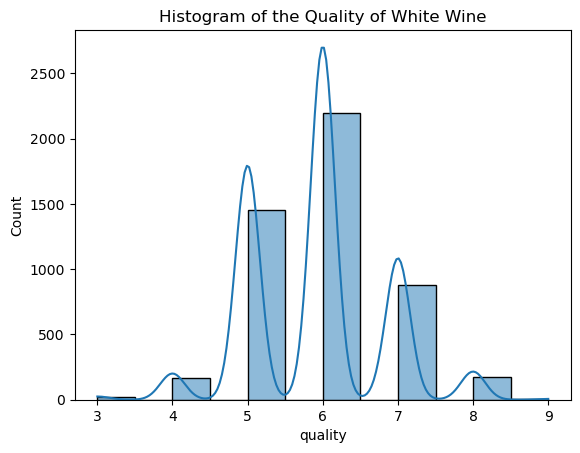

In [26]:
sns.histplot(dfr["quality"], kde = True, binwidth = 0.5)
plt.title("Histogram of the Quality of Red Wine")
plt.show()
sns.histplot(dfw["quality"], kde = True, binwidth = 0.5)
plt.title("Histogram of the Quality of White Wine")
plt.show()

Data that is normally distributed will create a symmetric, bell-shaped curve when plotted as a histogram. Looking at the two histograms, the two datasets don't quite make a symmetric bell curve (although the white wine data comes closer), with the red wine data leaning more to the right and the white wine data leaning a little more to the left, indicating that the datasets may be somewhat close to being normally distributed in terms of quality, but not quite.

Next, let's try a quantile-quantile plot, which compares ordered data with the expected quantiles of a normal distribution. If the points form a straight diagonal 45-degree line, the data is likely normally distributed. This time, Statsmodels can be used with Matplotlib to create this plot: 

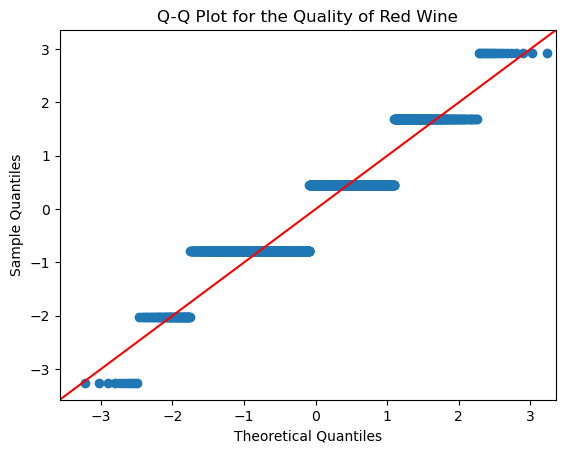

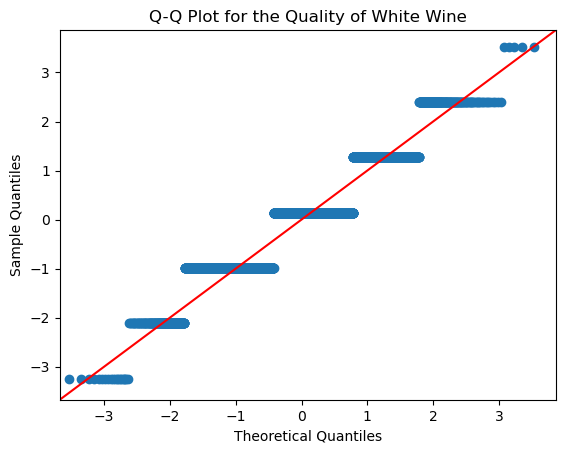

In [27]:
qqr = sm.qqplot(dfr["quality"], line = '45', fit = True)
plt.title("Q-Q Plot for the Quality of Red Wine")
plt.show()
qqw = sm.qqplot(dfw["quality"], line = '45', fit = True)
plt.title("Q-Q Plot for the Quality of White Wine")
plt.show()

For both datasets, the data forms horizontal "steps" that roughly follow along the quantiles of the normal distribution. Since our data is discrete quality-wise, this makes sense. Since the steps are mostly centered around the normal distribution line, these plots imply that the datasets might be normally distributed, or at least somewhat close.

Given the relative ambiguity of our plots, we should try running some tests with our data to come closer to a definite answer. D'Agostino-Pearson's Normal Test checks for normality based on skewness and kurtosis, and it's ideal for large sample sizes, which is perfect for our data. With Scipy, we can perform this test fairly easily:

In [28]:
stat_r, p_value_r = normaltest(dfr["quality"])
print(f"Statistic for red wine: {stat_r}; p-value for red wine: {p_value_r}")
stat_w, p_value_w = normaltest(dfw["quality"])
print(f"Statistic for white wine: {stat_w}; p-value for white wine: {p_value_w}")

Statistic for red wine: 17.26240081635554; p-value for red wine: 0.0001784503033385499
Statistic for white wine: 27.683238421253613; p-value for white wine: 9.74229231258065e-07


Looking at the results of the normal tests, the statistics are very large at double digits and the p-values for both of the datasets are well below 0.05, especially in the case of white wine, indicating that these datasets are not normally distributed.

Next, let's try the Kolmogorov-Smirnov Test, which is also provided by Scipy and is also well-suited for large sample sizes:

In [29]:
stat_r, p_value_r = kstest(dfr["quality"], "norm")
print(f"Statistic for red wine: {stat_r}; p-value for red wine: {p_value_r}")
stat_w, p_value_w = kstest(dfw["quality"], "norm")
print(f"Statistic for white wine: {stat_w}; p-value for white wine: {p_value_w}")

Statistic for red wine: 0.9986501019683699; p-value for red wine: 0.0
Statistic for white wine: 0.9986501019683699; p-value for white wine: 0.0


From the results of the K-S tests, the statistics for both datasets are very close to the maximum value of 1, and the p-values are reported as zero, indicating that the datasets are not normally distributed.

Let's try one more test provided by Scipy: The Jarque-Bera Test, which, like the normal test, is based on skewness and kurtosis and works best if the sample sizes are large:

In [30]:
stat_r, p_value_r = jarque_bera(dfr["quality"])
print(f"Statistic for red wine: {stat_r}; p-value for red wine: {p_value_r}")
stat_w, p_value_w = jarque_bera(dfw["quality"])
print(f"Statistic for white wine: {stat_w}; p-value for white wine: {p_value_w}")

Statistic for red wine: 18.300312588658564; p-value for red wine: 0.00010620320249092874
Statistic for white wine: 29.243113735213576; p-value for white wine: 4.4662037879326785e-07


From the results of these tests, the statistics are very large at double digits and the p-values are very small and well below 0.05 (especially with the white wine dataset). This implies that the datasets are not normally distributed.

On one last note, in normal distribution, the mean, median, and mode of the data are all identical, and with some functions provided by Panda, we can easily check for this:

In [31]:
mean_r = dfr["quality"].mean()
print(f"Red wine quality mean: {mean_r}")
median_r = dfr["quality"].median()
print(f"Red wine quality median: {median_r}")
mode_r = dfr["quality"].mode()[0]
print(f"Red wine quality mode: {mode_r}")
mean_w = dfw["quality"].mean()
print(f"White wine quality mean: {mean_w}")
median_w = dfw["quality"].median()
print(f"White wine quality median: {median_w}")
mode_w = dfw["quality"].mode()[0]
print(f"White wine quality mode: {mode_w}")

Red wine quality mean: 5.6360225140712945
Red wine quality median: 6.0
Red wine quality mode: 5
White wine quality mean: 5.87790935075541
White wine quality median: 6.0
White wine quality mode: 6


Looking at these results, the median and mode for the white wine dataset match, and the mean is somewhat close to those two values, possibly hinting at normal distribution, but in the red wine dataset, the three values differ noticeably, evidencing against normal distribution.

All in all, given these observations, combined with the results of the three tests, the histograms, and the Q-Q plots, we can some to an answer regarding one of our questions: <b>The red wine samples and white wine samples are not normally distributed in terms of quality.</b>

Lastly, let's try to find the impact of each feature variable on quality for both datasets. Using the <code>LinearRegression()</code> and <code>fit()</code> methods from Scikit-Learn will let us create a multiple linear regression model for all the feature variables on the quality variable. Likewise, the <code>intercept_</code> and <code>coef_</code> attributes will let us learn more about the regression models. Let's start with the red wine dataset:

In [32]:
r_model = LinearRegression().fit(dfr.drop(columns = ["quality"]), dfr["quality"])
print(f'Red wine linear regression: Intercept: {r_model.intercept_};\n Coefficients:\n {pd.Series(r_model.coef_, index = dfr.drop(columns = ["quality"]).columns)}')

Red wine linear regression: Intercept: 21.965208449448774;
 Coefficients:
 fixed acidity            0.024991
volatile acidity        -1.083590
citric acid             -0.182564
residual sugar           0.016331
chlorides               -1.874225
free sulfur dioxide      0.004361
total sulfur dioxide    -0.003265
density                -17.881164
pH                      -0.413653
sulphates                0.916334
alcohol                  0.276198
dtype: float64


Looking at this model, it seems as though fixed acidity, residual sugar, free sulfur dioxide, sulphates, and alcohol all increase red wine's quality, whereas volatile acidity, citric acid, chlorides, total sulfur dioxide, density, and pH all decrease red wine's quality. Furthermore, in terms of the size of the impact, density seems to have the largest impact by a wide margin, followed by chlorides, volatile acidity, sulphates, pH, alcohol, citric acid, fixed acidity, residual sugar, free sulfur dioxide, and total sulfur dioxide. Let's see the R-Squared score for this model to judge its accuracy:

In [33]:
print(f'R-Squared score: {r_model.score(dfr.drop(columns = ["quality"]), dfr["quality"])}')

R-Squared score: 0.3605517030386881


An R-Squared score of 0.36055170303868833 means that around 36% of the data in the red wine dataset can be explained by this regression model. This is a rather mediocre score overall, so perhaps a different type of model is in order.

Another way of mapping relationships between variables is the random forest regressor, which combines predictions from a variety of individual decision trees to predict numerical values. We can also create such a model using methods from Scikit-Learn:

In [34]:
X = dfr.drop(columns=["quality"])
Y = dfr["quality"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
r_tree = RandomForestRegressor(random_state=42)
r_tree.fit(X_train, Y_train)
r_train = r_tree.score(X_train, Y_train)
r_test = r_tree.score(X_test, Y_test)
print(f"R-Squared score on training data: {r_train}; R-Squared score on test data: {r_test}")

R-Squared score on training data: 0.9265672153390224; R-Squared score on test data: 0.5390429623873638


Already we can see some noticable improvement on the random forest regressor compared to the linear regression model, as the RFR manages to predict the training data with 92.7% accuracy and the test data with 53.9% accuracy. Let's see which feature variables the regressor finds most important with Pandas and Matplotlib:

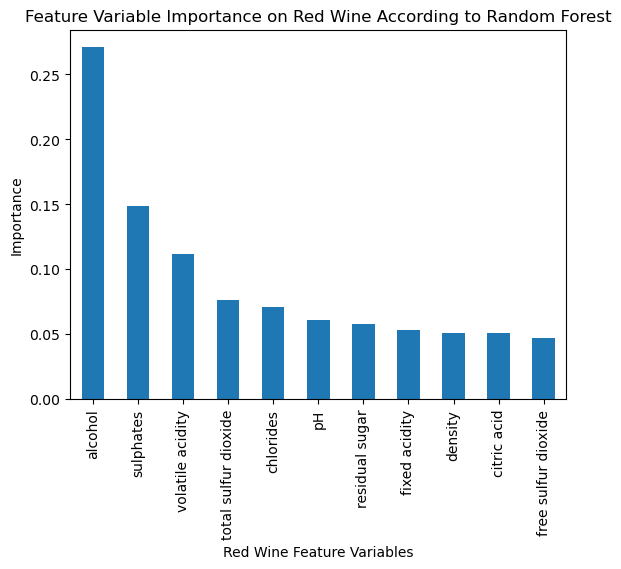

In [35]:
importances = pd.Series(r_tree.feature_importances_, index=X.columns).sort_values(ascending = False)
importances.plot(kind = 'bar')
plt.title("Feature Variable Importance on Red Wine According to Random Forest")
plt.ylabel("Importance")
plt.xlabel("Red Wine Feature Variables")
plt.show()

So, according to the random forest, the most important feature variable for red wine quality is alcohol by a wide margin at over 25%, followed by sulphates, volatile acidity, total sulfur dioxide, chlorides, pH, residual sugar, fixed acidity, density, citric acid, and free sulfur dioxide. But is there an even more accurate model we could try?

Scikit-Learn also provides us with the Histogram-Based Gradient Boosting Regression Tree, which uses a histogram-based approach for regression tasks. It is quite well suited for large datasets such as this one, so it's certainly worth giving try:

In [36]:
r_hist = HistGradientBoostingRegressor(random_state=42).fit(X_train, Y_train)
r_histscore = r_hist.score(X_test, Y_test)
print(f"The HGBR R-Squared Score: {r_histscore}")

The HGBR R-Squared Score: 0.4932815590126668


So, the HGBR can predict the test data with 49.3% accuracy. This is slightly lower than the random forest's 53.9% accuracy, so let's stick with the random forest for the red wine dataset. Now, let's try the random forest and the HGBR on the white wine dataset:

In [37]:
Xw = dfw.drop(columns=["quality"])
Yw = dfw["quality"]
Xw_train, Xw_test, Yw_train, Yw_test = train_test_split(Xw, Yw, test_size=0.2, random_state=42)
w_tree = RandomForestRegressor(random_state=42)
w_tree.fit(Xw_train, Yw_train)
w_train = w_tree.score(Xw_train, Yw_train)
w_test = w_tree.score(Xw_test, Yw_test)
print(f"R-Squared score on training data for the random forest: {r_train}; R-Squared score on test data for the random forest: {r_test}")
w_hist = HistGradientBoostingRegressor(random_state=42).fit(Xw_train, Yw_train)
w_histscore = w_hist.score(Xw_test, Yw_test)
print(f"The HGBR R-Squared Score: {w_histscore}")

R-Squared score on training data for the random forest: 0.9265672153390224; R-Squared score on test data for the random forest: 0.5390429623873638
The HGBR R-Squared Score: 0.49711825265194054


So, the random forest can predict the training data with 92.7% accuracy and the test data with 53.9% accuracy, while the HGBR can predict the test data with 49.7% accuracy. Again, the random forest possesses the superior accuracy, so let's use this model. Now, let's see which feature variables on the white wine dataset the random forest finds most important:

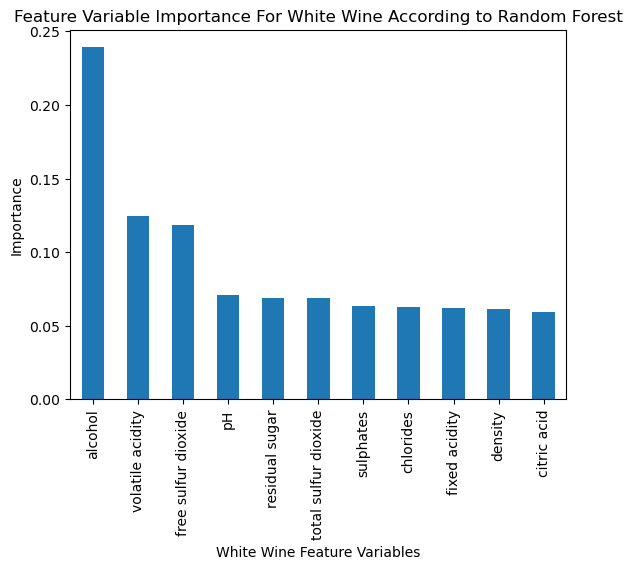

In [38]:
importances_w = pd.Series(w_tree.feature_importances_, index = Xw.columns).sort_values(ascending = False)
importances_w.plot(kind = 'bar')
plt.title("Feature Variable Importance For White Wine According to Random Forest")
plt.ylabel("Importance")
plt.xlabel("White Wine Feature Variables")
plt.show()

So, the most important feature variable in the white wine dataset for quality is alcohol by a wide margin at over 23%, followed by volatile acidity, free sulfur dioxide, pH, residual sugar, total sulfur dioxide, sulphates, chlorides, fixed acidity, density, and citric acid. So, judging from this bar graph and that of the red wine dataset, we can answer another one of our questions: <b>Alcohol, by far, has the biggest impact on wine quality in both datasets.</b>

To answer our last remaining question, it may be best to subtract the importances of the red wine dataset by those of the white wine dataset and examine the differences:

In [39]:
print(f"Importance differences:\n {importances - importances_w}")

Importance differences:
 alcohol                 0.031768
chlorides               0.008353
citric acid            -0.008752
density                -0.010659
fixed acidity          -0.009174
free sulfur dioxide    -0.071338
pH                     -0.009156
residual sugar         -0.011072
sulphates               0.085209
total sulfur dioxide    0.007955
volatile acidity       -0.013135
dtype: float64


Here, we can see that alcohol is 3.2% more important in red wine, chlorides are 0.8% more important in red wine, citric acid is 0.9% more important in white wine, density is 1.1% more important in white wine, fixed acidity is 0.9% more important in white wine, free sulfur dioxide is 7.1% more important in white wine, pH is 0.9% more important in white wine, residual sugar is 1.1% more important in white wine, sulphates are 8.5% more important in red wine, total sulfur dioxide is 0.8% more important in red wine, and volatile acidity is 1.3% more important in white wine. So, we can answer our last question: <b>Alcohol, chlorides, sulphates, and total sulfur dioxide are more important in red wine, whereas citric acid, density, fixed acidity, free sulfur dioxide, pH, residual sugar, and volatile acidity are more important in white wine.</b>

# Conclusion

Overall, our observations indicate that alcohol has the largest impact on wine quality in both datasets by a wide margin. Moreover, in red wine, alcohol, chlorides, sulphates, and total sulfur dioxide have a larger impact on quality than in white wine, whereas citric acid, density, fixed acidity, free sulfur dioxide, pH, residual sugar, and volatile acidity have a bigger impact on quality in white wine than in red wine. Also, white wine tends a yield a slightly higher quality on average than red wine, and in terms of feature variables, red wine generally has significantly higher fixed acidity, noticably higher volatile acidity, somewhat more chlorides, slightly higher density, noticably higher pH, and noticably more sulphates, while white wine generally has somewhat higher citric acid, significantly higher residual sugar, significantly higher free sulfur dioxide, significantly higher total sulfur dioxide, and marginally more alcohol. Lastly, the quality of the two sets of wine is not normally distributed.